In [16]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from  sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [17]:
#configurations
pd.set_option('display.max_columns', None)
pd.set_option("float_format", "{:.3f}".format)
sns.set_style("darkgrid")

plt.rcParams.update({
    "figure.figsize":(10,6),
    "axes.titlesize":16,
    "axes.labelsize":14,
    "xtick.labelsize":12,
    "ytick.labelsize":12
})

RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET_COL ="charges"
DATASET_PATH= r"C:\Users\Xpensive\Desktop\Ml_med_Insurance\dataset\insurance_for_med.csv"

LOADING DATA

In [18]:
df = pd.read_csv(DATASET_PATH)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [19]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1338, 7)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [22]:
#checking for duplicates
duplicates = df.duplicated()
num_duplicates = duplicates.sum()
print("Number of Duplicates:", num_duplicates)

Number of Duplicates: 1


In [23]:
#checking for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [24]:
#splitting features into numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']


In [25]:
#descriptive statistics for numerical columns
df[numerical_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


In [27]:
#checking for unique values
for col in categorical_cols:
    print(f"Unique values cols in {col}: {df[col].unique()}")
    print(f"Unique Counts cols in {col}: {df[col].value_counts()}")

Unique values cols in sex: ['female' 'male']
Unique Counts cols in sex: sex
male      676
female    662
Name: count, dtype: int64
Unique values cols in smoker: ['yes' 'no']
Unique Counts cols in smoker: smoker
no     1064
yes     274
Name: count, dtype: int64
Unique values cols in region: ['southwest' 'southeast' 'northwest' 'northeast']
Unique Counts cols in region: region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [28]:
for col in df.columns:
    print(col, df[col].nunique())

age 47
sex 2
bmi 548
children 6
smoker 2
region 4
charges 1337


DATA VISUALIZATION

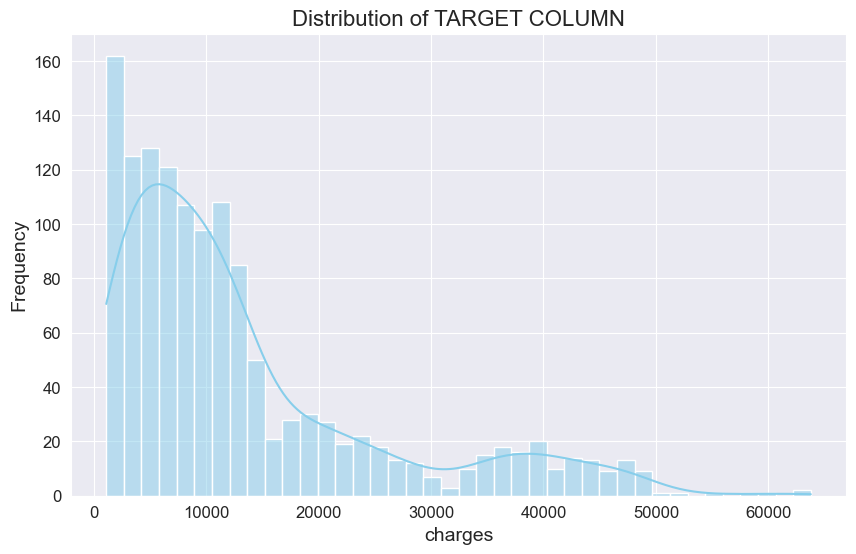

In [29]:
#TARGET COLUMN DISTRIBUTION
plt.figure(figsize=(10,6))
sns.histplot(df[TARGET_COL], bins=40, kde=True, color='skyblue')
plt.xlabel(TARGET_COL)
plt.ylabel('Frequency')
plt.title("Distribution of TARGET COLUMN")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

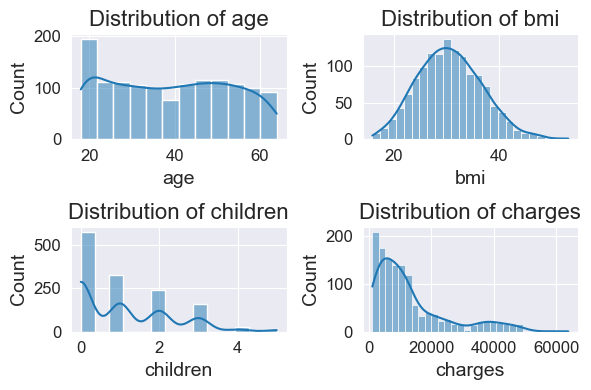

In [31]:
fig, axes = plt.subplots(2,2, figsize = (6,4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax = axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show

<Axes: >

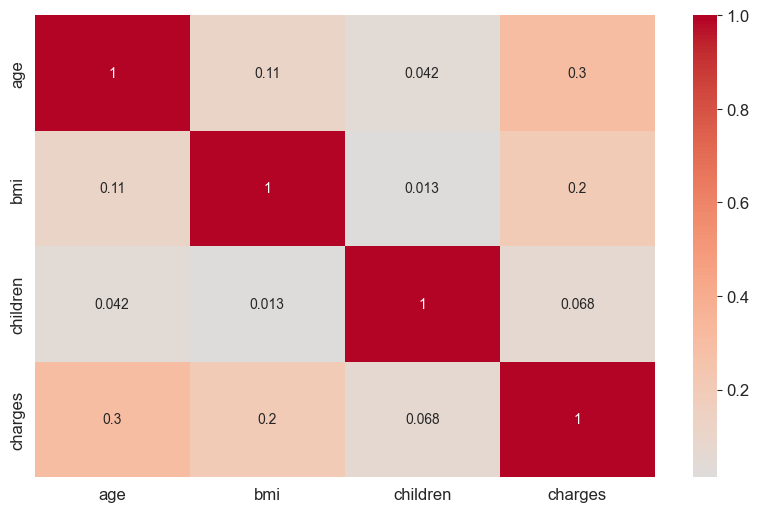

In [33]:
#Identifying highly correlated features
plt.figure(figsize=(10,6))
sns.heatmap(
    df[numerical_cols].corr(),
     annot=True,
     cmap='coolwarm',
     center=0
    )

In [35]:
#correlation of features with the target variable
df[numerical_cols].corr()[TARGET_COL].sort_values(ascending=False)

charges    1.000
age        0.299
bmi        0.198
children   0.068
Name: charges, dtype: float64

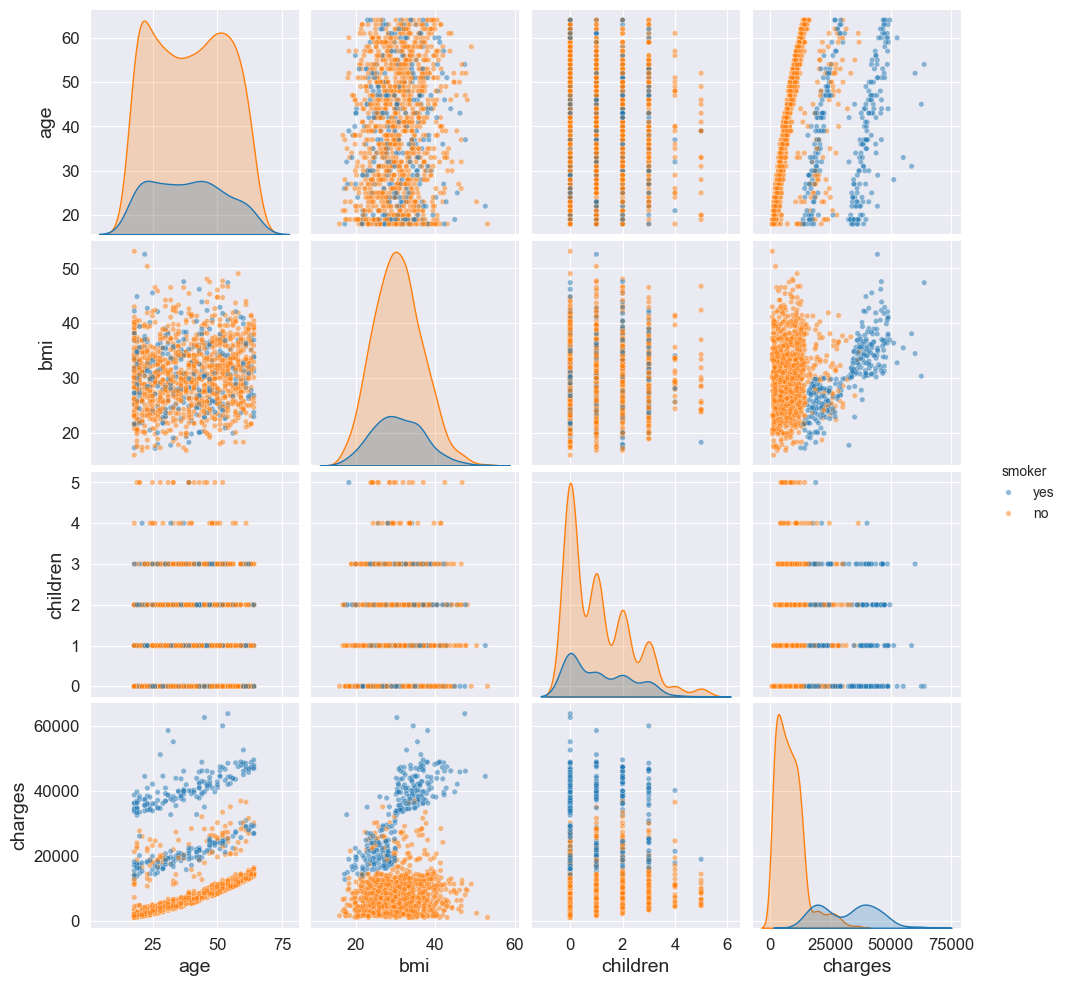

In [37]:
#generating pair plots
sns.pairplot(df,
             vars=numerical_cols,
             diag_kind='kde',
             hue="smoker",
             plot_kws={'alpha':0.5,'s':15})
plt.show()

DATA PREPROCESSING

In [38]:
#Separating features and target variables
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [39]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [40]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [41]:
#splitting dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [42]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1003, 6)
Test shape: (335, 6)


PREPROCESSING PIPELINE

In [43]:
numerical_features = X.select_dtypes(include=[np.number]).columns.to_list()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.to_list()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']


In [44]:
numerical_pipeline = Pipeline(
    steps=[("scaler",StandardScaler())]
)

categorical_pipeline = Pipeline(
    steps=[("onehot", OneHotEncoder())]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline,numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

BASE PIPELINE

In [46]:
base_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [47]:
#training the data and the training the model
base_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [48]:
#Evaluation of Base Pipeline
train_baseline_pred = base_pipe.predict(X_train)
test_baseline_pred = base_pipe.predict(X_test)

In [49]:
train_baseline_pred[:5]

array([ 1821.07697573,  4210.87812211, 14204.47142399, 35645.17999288,
        9617.33921854])

In [50]:
y_train[:5]

693     2352.968
1297    4340.441
634     9391.346
1022   42211.138
178     8823.279
Name: charges, dtype: float64

In [52]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n =======Baseline Model Performance on Training Set=======")
print(f"RMSE: {train_baseline_rmse}")
print(f"MAE : {train_baseline_mae}")
print(f"r2 score: {train_baseline_r2}")


 =======Baseline Model Performance on Training Set=======
RMSE: 6083.132596294014
MAE : 4183.1533670119725
r2 score: 0.7449555328228536


In [51]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n =======Baseline Model Performance on Test Set=======")
print(f"RMSE: {test_baseline_rmse}")
print(f"MAE : {test_baseline_mae}")
print(f"r2 score: {test_baseline_r2}")


 =======Baseline Model Performance on Test Set=======
RMSE: 5926.023602394469
MAE : 4243.654116653143
r2 score: 0.7672642952734356


MODEL SELECTION & OPTIMIZATION

In [53]:
 #Models to try
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "DecisionTree" : DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest" : RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost" : XGBRegressor(random_state=RANDOM_STATE)
}

In [54]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [55]:
scoring = {
    "mae" : "neg_mean_absolute_error",
    "rmse" : "neg_root_mean_squared_error",
    "r2" : "r2"
}